### ✅ LLM + Bert 모델 응용 어플리케이션(bert_llm 결합 모델)

- 이 파일 BERT 기반 정서 분류 결과를 GPT 모델이 해석하여 대상자의 종합 심리 상태 보고서를 생성하는 응용 예제(데모)버전으로 추후 개선 여지가 있음
- 어플리케이션 프로그램에 들어가는 주요 함수를 이해하기 쉽게 풀어쓴 노트북입니다.
- 판단 AI 모델: Bert 모델 파인튜닝
- 종합 심리 상태 보고서: gemma3.gguf (랭체인, 랭그래프로 AI Agent 구성)
- 장점: gpu 없이 로컬 가정용 cpu 환경에서도 가동 가능
- 추후 확장 가능성 -> 해당 내용을 종합적으로 LLM이 판단하여 등급별로 다른 기능 수행
<br>EX) emerency : 119 or 112 연계 / critical: 지자체 공무원 연락 / danger: 보호자 및 가족들에게 알림

#### 👉 패키지 로드 

In [ ]:
!pip install -r requirements.txt

In [5]:
# bert 모델
from transformers import AutoTokenizer,AutoModelForSequenceClassification
import torch

# llama-cpp-python을 사용하는 GGUF 모델 로더
from langchain_community.chat_models import ChatLlamaCpp
from langchain_core.prompts import ChatPromptTemplate
# 랭그래프 및 타입선언
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import List,Annotated, Optional 
from typing_extensions import TypedDict

import pandas as pd
from io import StringIO

c:\Users\user\OneDrive\바탕 화면\새 폴더\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 👉 학습된 BERT 모델 호출
- 허깅페이스에서 kcbert 모델 다운

> 📖 참고문헌<br>
Lee, Junbum. (2020). **KcBERT: Korean Comments BERT.**
  *Proceedings of the 32nd Annual Conference on Human and Cognitive Language Technology (HCLT 2020)*, pp. 437–440.



In [6]:
# === bert 모델 === 
# 저장된 기존 로컬 모델
local_path = "../model/kcbert_local"

tokenizer = AutoTokenizer.from_pretrained(local_path)
model = AutoModelForSequenceClassification.from_pretrained(local_path, num_labels=4)

# 학습된 가중치 로드 
state_dict = torch.load("../model/best_kcbert_model.pt", map_location="cpu")
state_dict = state_dict["model_state_dict"]
model.load_state_dict(state_dict)
model.eval()
print("✅ 오프라인 로드 성공")

# === 테스트 === 
text = "사람이 살아가다 보면 생각하지도 못한 일들이 한꺼번에 몰려올 때가 있습니다. 그런 순간에는 잠시 멈춰서 호흡을 고르고, 자신이 어디쯤에 서 있는지를 돌아보는 게 중요합니다. 세상은 늘 변하고 있고"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

ranks = ['positive','danger' ,'critical','emergency']
    
print("출력 logits:", outputs.logits)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../model/kcbert_local and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 오프라인 로드 성공


c:\Users\user\OneDrive\바탕 화면\새 폴더\.venv\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


출력 logits: tensor([[-0.5965,  3.0921, -0.6229, -2.3071]])


#### 👉 LLM 랭체인으로 호출(BASE LLM)

In [7]:
# ===  모델 생성 ====
model_path = "../model/gemma-3-1B-it-QAT-Q4_0.gguf"

raw_llm = ChatLlamaCpp(
    model_path= model_path,
    n_ctx=4096,  # 컨텍스트 길이 설정 (길수록 더 많은 대화 기억)
    n_gpu_layers=35, # GPU 오프로드 레이어 수 (선택 사항, 성능 향상 목적)
    temperature=0.0,
    verbose=False,
)

print("\n===🎯Gemma3 테스트===")
print("질문: 안녕하세요")
print('답변: ', raw_llm.invoke('안녕하세요?').content)

llama_context: n_batch is less than GGML_KQ_MASK_PAD - increasing to 64
llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
llama_kv_cache_unified_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)



===🎯Gemma3 테스트===
질문: 안녕하세요
답변:  안녕하세요! 무엇을 도와드릴까요? 😊



#### 👉 랭그래프로 AI-agent 구성
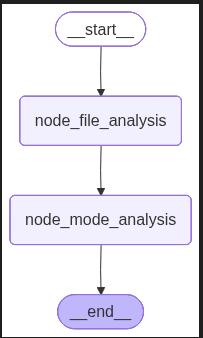

In [8]:
# ===  Graph State 정의 ====

# state 정의
class State(TypedDict):
    path: Annotated[str, '파일 위치'] 
    doll_id: Annotated[str,'화자 ID']
    df_merged: Optional[str] 

'''노드 구성-대화턴 연결(10분 이상 초과 시 다른 대화로 간주)'''
def node_file_analysis(state:State)->State:

    # 파일 경로 불러오기 
    df= pd.read_excel(state['path'])
    df = df[df['doll_id'] == state['doll_id']].copy()
    df['uttered_at'] = pd.to_datetime(df['uttered_at'])
    df_list = [] 
    for y,sub in df.groupby(['doll_id']):

        sub['min'] = sub['uttered_at'].diff() > pd.Timedelta(minutes=10)
        # True가 나올 때마다 그룹이 바뀌도록 누적 그룹 번호 생성
        sub["group"] = sub["min"].cumsum()

        # False만 묶어서 텍스트 합치기
        merged = (
            sub.groupby(["group", "min"])
            .agg({
                "text": lambda x: " ".join(x) if not x.empty else "",
                "uttered_at": "first"
            })
            .reset_index(drop=True)
        )

        # 최종 결과
        merged['doll_id'] = y[0]
        df_list.append(merged)

    merge_df = pd.concat(df_list)   
    df_json_str = merge_df.to_json(orient='split', date_format='iso')
    
    return {
        "df_merged": df_json_str, # DataFrame 객체를 상태에 저장
        }


'''노드 구성-대화턴 연결(10분 이상 초과 시 다른 대화로 간주)'''
def node_mode_analysis(state:State)->State:

    # json 파일 불러오기
    
    df_restored = pd.read_json(
        StringIO(state['df_merged']), 
        orient='split', 
        convert_dates=['uttered_at'] # 날짜 복원을 위해 추가
    )
    
    ranks = ['positive','danger' ,'critical','emergency']
    # bert 모델로 등급 정도 판단하기 
    answers = list()
    ranks_list = list()
    for text in df_restored['text']:

        inputs = tokenizer(text, return_tensors="pt")

        with torch.no_grad():
            outputs = model(**inputs)

        # 결과 저장
        answer = ranks[outputs.logits[0].argmax()]
        ranks_list.append(answer)
        # llm 불러오기 
        first_prompt_str = """
        당신은 등급 판별자가 아닙니다. 이미 다른 시스템이 문장의 위험 등급을 판정했습니다.  
        당신의 임무는 **판단된 등급을 그대로 유지한 채**, 그 이유만 논리적으로 설명하는 것입니다.  
        새로운 판단, 재분류, 반박, 평가를 해서는 안 됩니다.

        - 위험 등급 순서: positive → danger → critical → emergency  
        - 위험 등급 정의:
            • positive: 정서적으로 안정적이며 긍정적인 감정을 표현한 상태. 희망·감사·행복 등의 표현을 포함.
            • danger: 불안·무기력 등 부정적 감정이 드러나지만 즉각적인 위험은 없는 상태. 
            • critical: 절망·자책 등 심리적 위기 신호가 명확히 드러나는 상태.
            • emergency: 자살·자해 등 즉각적인 개입이 필요한 긴급 위험 상태. 

        - 이 문장은 이미 "{answer}" 등급으로 분류되었습니다.  
        - 당신은 이 결과를 그대로 인정해야 하며, 해당 등급으로 판단할수 없다라는 말을 하지 마세요

        분석 대상 문장:
        "{text}"

        출력 형식(이 형식을 반드시 그대로 따르십시오):
        문장: "{text}"
        판단 근거: (해당 문장이 '{answer}' 등급으로 분류된 이유를 설명.  
        이유는 반드시 '{answer}'가 맞다는 방향으로 작성해야 하며, 부정하거나 반박하지 마십시오.)
        """

        # 템플릿 제작: system_prompt_str을 사용
        template = ChatPromptTemplate.from_messages([
            ('system', first_prompt_str),  # {format_instructions} 템플릿 변수가 등록됨
            ('user', "{input}"),
        ])
        messages = template.format_messages(
            answer=answer,
            text=text,
            input=text
        )

        # 실제 LLM 호출
        response = raw_llm.invoke(messages)
        answers.append(response)
    df_restored['판단근거'] = answers
    df_restored['정답'] = ranks_list

    df_json_str = df_restored.to_json(orient='split', date_format='iso')
        
    return {
            "df_merged": df_json_str, # DataFrame 객체를 상태에 저장
    }

# 그래프 연결
graph = StateGraph(State)
graph.add_node("node_file_analysis", node_file_analysis)
graph.add_node("node_mode_analysis", node_mode_analysis)
graph.add_edge(START,"node_file_analysis")
graph.add_edge('node_file_analysis',"node_mode_analysis")
graph.add_edge("node_mode_analysis",END)

# 메모리 기억 장치 
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
config = {"configurable":{"thread_id":"abcdq"}} # 쓰레드 별로 저장
app = graph.compile(checkpointer=memory)

#### ❗모델 테스트
- doll_id: 화자 id 입력
- path: 파일 경로

- json 형태로 나오기 때문에 이를 데이터 프레임으로 변환

In [ ]:
path='../data/(원본데이터)발화데이터(대전중구).xlsx'
final_list = []
# 상기부분에서는 테스트 겸으로 22명만 산출
for x in range(1,22):
    results = app.invoke({'path':path,'doll_id':x}, config={"configurable": {"thread_id": "abcdq"}})

    print(f"===🎯json =>{x}번째 데이터 프레임으로 변환===")
    df_restored = pd.read_json(
        StringIO(results['df_merged']), 
        orient='split', 
        convert_dates=['uttered_at'] # 날짜 복원을 위해 추가
    )
    df_restored['판단근거'] = [x['content']for x in df_restored['판단근거']]
    df_restored.rename(columns={'정답':'위험도 등급'},inplace=True)
    final_list.append(df_restored)

final_df= pd.concat(final_list)
final_df= final_df[['doll_id','text','uttered_at','위험도 등급','판단근거']]
print('첫번째 화자 말씀')
print(final_df.iloc[0]['판단근거'])
final_df.to_excel('(분석결과)발화데이터(대전중구).xlsx',index=False)